# 예측 모델 실습

### auto-mpg.csv 데이터를 통해,  
### mpg (mile per gallern, 자동차 연비)  를 예측하는 모델을 만드세요.

컬럼 정보 :

MPG (miles per gallon - 연비),

cylinders (실린더 갯수)

engine displacement (inches 배기량),

horsepower (마력),

vehicle weight (lbs. 무게),

time to accelerate from O to 60 mph (sec. 60mph까지 걸리는 시간),

model year ,

origin of car (1. American,   2. European,   3. Japanese).

Also provided are the car labels (types)



In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [55]:
df = pd.read_csv('../data/auto-mpg.csv')

In [56]:
df.head(2)

,mpg,cyl,displ,hp,weight,accel,yr,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320


In [57]:
df.isna().sum()

mpg       0
cyl       0
displ     0
hp        0
weight    0
accel     0
yr        0
origin    0
name      0
dtype: int64

In [64]:
y = df['mpg']

In [65]:
X = df.loc[ : ,'cyl' : 'origin']

In [60]:
X.info() # => 문자열 있는지 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cyl     392 non-null    int64  
 1   displ   392 non-null    float64
 2   hp      392 non-null    int64  
 3   weight  392 non-null    int64  
 4   accel   392 non-null    float64
 5   yr      392 non-null    int64  
 6   origin  392 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 21.6 KB


In [61]:
y # =>문자열 있는지 확인

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
387    27.0
388    44.0
389    32.0
390    28.0
391    31.0
Name: mpg, Length: 392, dtype: float64

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [76]:
X_train.shape

(313, 7)

In [77]:
from sklearn.linear_model import LinearRegression

In [78]:
regressor = LinearRegression()

In [79]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_pred = regressor.predict(X_test)

In [86]:
((y_test - y_pred)**2).mean()  # => MSE

np.float64(12.440699176751943)

In [95]:
# => MSE 모듈
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [91]:
mean_squared_error(y_test, y_pred)  #MSE

12.440699176751943

In [92]:
root_mean_squared_error(y_test, y_pred) #RMSE

3.5271375330077426

In [94]:
mean_absolute_error(y_test, y_pred) #MAE

2.5840040608985895

In [96]:
# R2 = R Squared => 0~1사이의 값으로 나오는데, 1로 나올수록 성능이 좋다
r2_score(y_test, y_pred)

0.7893105393729918

In [99]:
df_test = y_test.to_frame().reset_index(drop=True)

In [100]:
df_test

,mpg
0,44.0
1,33.0
2,34.1
3,13.0
4,26.0
...,...
74,13.0
75,15.0
76,18.5
77,19.4


In [101]:
df_test['y_pred'] = y_pred

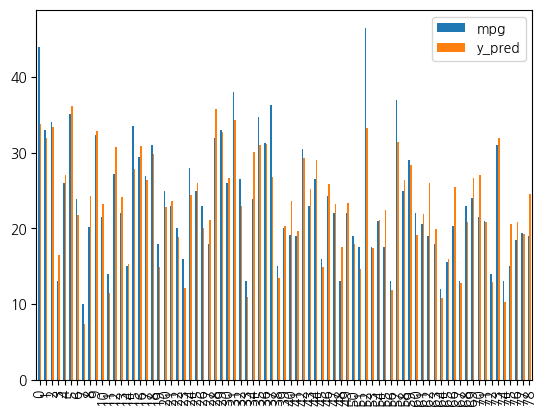

<Figure size 640x480 with 0 Axes>

In [109]:
df_test.plot(kind='bar')
plt.show()
plt.tight_layout()

In [107]:
# 차트 한글처리
from koreanize_matplotlib import koreanize
koreanize()

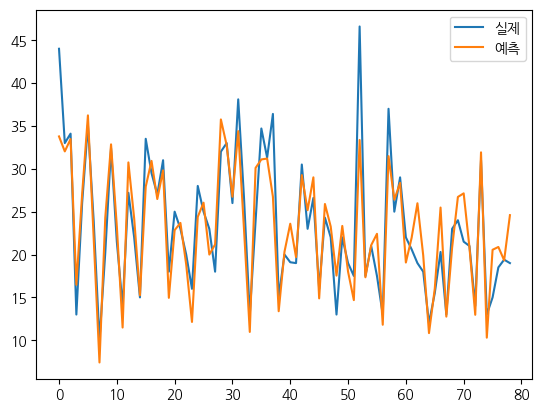

In [108]:
plt.plot(y_test.values) # =>판다스 시리즈 => values로 값만 꺼내기
plt.plot(y_pred) # => 넘파이=데이터 자체 => values 안씀
plt.legend(['실제','예측'])
plt.show()

### 연습문제

In [113]:
df = pd.read_csv('../data/ecommerce.csv', index_col=0)

In [117]:
df.head()
# dayofweek =[ 0=월요일, 1=화요일, 2=수요일...]
# Isholiday = 휴일

,DayOfWeek,IsHoliday,MarketingSpend,CompetitorPrice,Price,Month,Sales
0,0,0,76,21125,24926,1,295
1,1,1,74,22287,27811,1,210
2,2,0,42,19364,26016,1,207
3,3,0,49,23621,23335,1,220
4,4,0,83,24431,27068,1,201


In [121]:
df['IsHoliday'].unique()

array([0, 1])

In [122]:
df['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [123]:
df.describe()
df.isna().sum()

DayOfWeek          0
IsHoliday          0
MarketingSpend     0
CompetitorPrice    0
Price              0
Month              0
Sales              0
dtype: int64

## *상관관계 분석 correlation analysis, (컬럼간의 관계) * 중요함!!
- 상관관계 분석이란 :     
  => 두 변수 또는 여러 변수들이 서로 어떤 [선형적인 연관성]을 가지고 변화하는지 그 관계의 정도를 수치로 평가하는 분석 방법  
  => 비례, 반비례, 아무x  
- 상관관계 분석은 :  
  => "상관계수"라는 수치를 통해 두 변수 간의 연관 정도를 나타냅니다.  
   이 값은 -1(완전 음의 상관)부터 1(완전 양의 상관), 0(상관 없음) 사이의 값을 가집니다    

- r이 -1.0과 -0.7 사이이면, 강한 음적 선형관계,  
r이 -0.7과 -0.3 사이이면, 뚜렷한 음적 선형관계,  
r이 -0.3과 -0.1 사이이면, 약한 음적 선형관계,  
r이 -0.1과 +0.1 사이이면, 거의 무시될 수 있는 선형관계,  
r이 +0.1과 +0.3 사이이면, 약한 양적 선형관계,  
r이 +0.3과 +0.7 사이이면, 뚜렷한 양적 선형관계,  
r이 +0.7과 +1.0 사이이면, 강한 양적 선형관계  

In [125]:
# 상관관계 분석 = 중요!!
df.corr()

,DayOfWeek,IsHoliday,MarketingSpend,CompetitorPrice,Price,Month,Sales
DayOfWeek,1.000000,-0.101485,-0.027126,0.058028,0.054830,-0.001853,-0.076832
IsHoliday,-0.101485,1.000000,0.007405,-0.042057,-0.034416,-0.009566,0.121911
MarketingSpend,-0.027126,0.007405,1.000000,0.024803,-0.041695,0.012718,0.582831
CompetitorPrice,0.058028,-0.042057,0.024803,1.000000,0.066226,0.033093,-0.297661
Price,0.054830,-0.034416,-0.041695,0.066226,1.000000,-0.078575,-0.703286
Month,-0.001853,-0.009566,0.012718,0.033093,-0.078575,1.000000,-0.185007
Sales,-0.076832,0.121911,0.582831,-0.297661,-0.703286,-0.185007,1.000000


In [126]:
df[['IsHoliday','MarketingSpend']].corr()

,IsHoliday,MarketingSpend
IsHoliday,1.000000,0.007405
MarketingSpend,0.007405,1.000000


In [127]:
df[['IsHoliday','Sales']].corr()

,IsHoliday,Sales
IsHoliday,1.000000,0.121911
Sales,0.121911,1.000000


In [128]:
df[['Price','CompetitorPrice','Sales']].corr()

,Price,CompetitorPrice,Sales
Price,1.000000,0.066226,-0.703286
CompetitorPrice,0.066226,1.000000,-0.297661
Sales,-0.703286,-0.297661,1.000000


In [129]:
# 파이차트? => 퍼센테이지로 나타내고 싶을때 사용

In [130]:
# 두 컬럼간의 관계? => 스케터

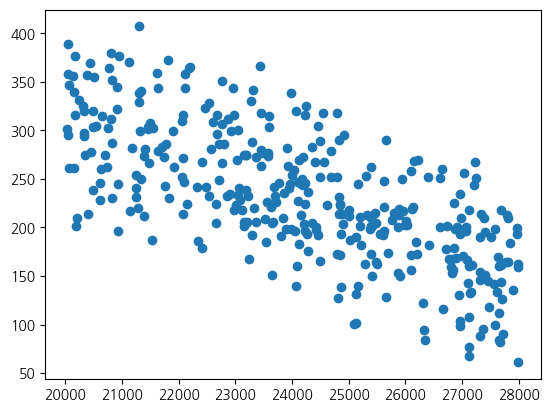

In [132]:
# => 스케터 
plt.scatter(data = df, x='Price', y= 'Sales')
plt.show()  # =>\(반비례관계)

In [136]:
df[['Price','Sales']].corr()

,Price,Sales
Price,1.000000,-0.703286
Sales,-0.703286,1.000000


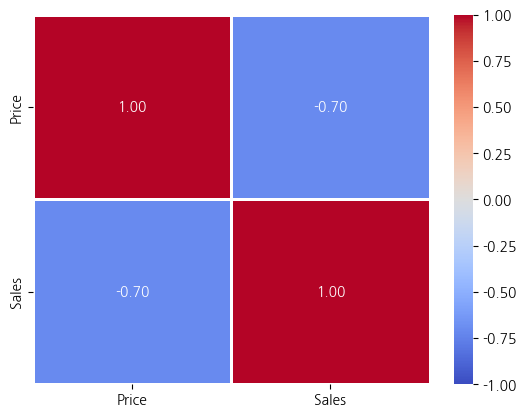

In [141]:
sb.heatmap(data = df[['Price','Sales']].corr(), linewidths=0.8 , vmin=-1,vmax=1 , cmap='coolwarm',
          annot=True, fmt='.2f')
plt.show()

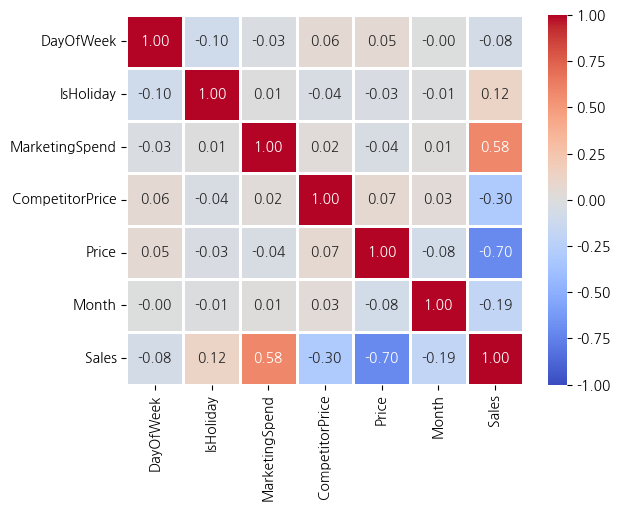

In [143]:
# 전체데이터 상관관계 비교시 heatmap 사용하면 보기 편해짐
sb.heatmap(data = df.corr(), linewidths=0.8 , vmin=-1,vmax=1 , cmap='coolwarm',
          annot=True, fmt='.2f')
plt.show()

In [144]:
df

,DayOfWeek,IsHoliday,MarketingSpend,CompetitorPrice,Price,Month,Sales
0,0,0,76,21125,24926,1,295
1,1,1,74,22287,27811,1,210
2,2,0,42,19364,26016,1,207
3,3,0,49,23621,23335,1,220
4,4,0,83,24431,27068,1,201
...,...,...,...,...,...,...,...
360,3,0,65,24232,24854,1,224
361,4,0,95,21161,21804,1,372
362,5,0,23,22293,23212,1,206
363,6,0,99,24797,25393,1,262


In [145]:
y = df['Sales']

In [146]:
X = df.loc[ : , 'DayOfWeek':'Month'] # or X=df.drop('Sales', axis= 1)

In [148]:
X.info()
y.info()

<class 'pandas.core.series.Series'>
Index: 365 entries, 0 to 364
Series name: Sales
Non-Null Count  Dtype
--------------  -----
365 non-null    int64
dtypes: int64(1)
memory usage: 5.7 KB


In [163]:
from sklearn.model_selection import train_test_split

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [165]:
X_train.shape

(292, 6)

In [166]:
from sklearn.linear_model import LinearRegression

In [169]:
regressor = LinearRegression()

In [170]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [171]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [174]:
y_pred = regressor.predict(X_test)

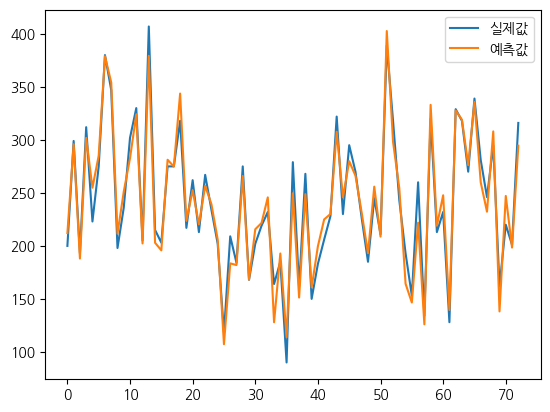

In [184]:
plt.plot(y_test.values)
plt.plot(y_pred)
plt.legend(['실제값','예측값'])
plt.show()

In [175]:
((y_test - y_pred)**2).mean()

np.float64(229.31342609774293)

In [177]:
from sklearn.metrics import mean_squared_error, r2_score

In [178]:
mean_squared_error(y_test, y_pred)

229.31342609774293

In [185]:
r2_score(y_test,y_pred)

0.9459055792934629

### [ 리그레션에 많이 사용하는 2가지를 더 알아보자 ] 
- RandomForest
- XGBoost  

In [186]:
from sklearn.ensemble import RandomForestRegressor

In [204]:
regressor2 = RandomForestRegressor(n_estimators= 500 , random_state= 7)

In [205]:
regressor2.fit(X_train,y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [206]:
y_pred2 = regressor2.predict(X_test)

### 실제값과 리니어리그레션 예측값과 랜덤포레스트의 예측값을 전부 합쳐서 보자

In [207]:
df_test = y_test.to_frame().reset_index(drop=True)

In [208]:
df_test['linear'] = y_pred

In [209]:
df_test['random'] = y_pred2

In [210]:
df_test

,Sales,linear,random
0,200,212.108617,199.878
1,299,295.857813,271.646
2,193,188.049792,196.644
3,312,301.899887,314.754
4,223,254.889004,257.008
...,...,...,...
68,295,308.007863,300.432
69,162,138.187057,154.194
70,220,247.113071,254.896
71,201,198.408146,191.466


In [211]:
# 리니어리그레션
mean_squared_error(y_test,y_pred)

229.31342609774293

In [212]:
# 랜덤포레스트
mean_squared_error(y_test,y_pred2)

460.35025523287663

In [213]:
# r2(제곱)
r2_score(y_test, y_pred)

0.9459055792934629

In [214]:
r2_score(y_test, y_pred2)

0.8914046124437802

In [216]:
! pip install xgboost

In [217]:
from xgboost import XGBRegressor

In [243]:
regressor3 = XGBRegressor(n_estimators = 100, random_state=7)

In [244]:
regressor3.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [245]:
y_pred3 = regressor3.predict(X_test)

In [246]:
# 데이터프레임에 합쳐보기
df_test['xgboost'] = y_pred3

In [247]:
df_test

,Sales,linear,random,xgboost
0,200,212.108617,199.878,213.833084
1,299,295.857813,271.646,271.939270
2,193,188.049792,196.644,204.379944
3,312,301.899887,314.754,301.833893
4,223,254.889004,257.008,255.649231
...,...,...,...,...
68,295,308.007863,300.432,291.036438
69,162,138.187057,154.194,171.589478
70,220,247.113071,254.896,246.165588
71,201,198.408146,191.466,219.222427


In [248]:
mean_squared_error(y_test, y_pred)

229.31342609774293

In [249]:
mean_squared_error(y_test, y_pred2)

460.35025523287663

In [250]:
mean_squared_error(y_test, y_pred3)

391.2726745605469

In [251]:
r2_score(y_test, y_pred)

0.9459055792934629

In [252]:
r2_score(y_test, y_pred2)

0.8914046124437802

In [253]:
r2_score(y_test, y_pred3)

0.9076998233795166

In [375]:
# 파이프라이닝, 그리드서치
df = pd.read_csv('../data/healthcare.csv', index_col=0)

In [376]:
df.head()

,Age,Gender,BMI,Region,Smoker,NumVisits,InsuranceClaim
0,51.0,Female,NaN,South,No,19.0,70.081987
1,92.0,Female,38.074006,West,Yes,13.0,92.747518
2,14.0,Male,NaN,North,No,8.0,46.794138
3,NaN,Female,27.020924,West,No,7.0,44.789132
4,60.0,Male,37.961368,North,No,16.0,71.790344


In [377]:
df.isna().sum()

Age               30
Gender             0
BMI               50
Region             0
Smoker             0
NumVisits         20
InsuranceClaim     0
dtype: int64

In [378]:
df.dropna(inplace=True)

In [379]:
df.isna().sum()

Age               0
Gender            0
BMI               0
Region            0
Smoker            0
NumVisits         0
InsuranceClaim    0
dtype: int64

In [380]:
df.shape

(407, 7)

In [381]:
y = df['InsuranceClaim']

In [382]:
X = df.drop('InsuranceClaim', axis = 1)

In [383]:
X.head()

,Age,Gender,BMI,Region,Smoker,NumVisits
1,92.0,Female,38.074006,West,Yes,13.0
4,60.0,Male,37.961368,North,No,16.0
5,20.0,Female,29.676706,East,No,1.0
6,82.0,Male,15.821167,North,No,2.0
7,86.0,Male,37.818737,East,No,7.0


In [384]:
y.head(3)

1    92.747518
4    71.790344
5    39.417650
Name: InsuranceClaim, dtype: float64

In [385]:
sorted(df['Gender'].unique())

['Female', 'Male']

In [387]:
sorted(df['Region'].unique())

['East', 'North', 'South', 'West']

In [388]:
sorted(df['Smoker'].unique())

['No', 'Yes']

In [287]:
df.head(2)

,Age,Gender,BMI,Region,Smoker,NumVisits,InsuranceClaim
1,92.0,Female,38.074006,West,Yes,13.0,92.747518
4,60.0,Male,37.961368,North,No,16.0,71.790344


In [389]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler

In [390]:
from sklearn.compose import ColumnTransformer

In [391]:
ct = ColumnTransformer( [ ('label', OrdinalEncoder(),[1,4]),
                          ('onehot', OneHotEncoder(), [3]),
                          ('scaler', MinMaxScaler(), [0, 2, 5]) ] ) 

In [392]:
regressor = LinearRegression()

### 파이프라이닝 적용하기

In [393]:
from sklearn.pipeline import Pipeline

In [394]:
pipe = Pipeline( steps= [('preprocessing', ct ),
                        ('regressor', regressor)])

In [396]:
X.head(2)

,Age,Gender,BMI,Region,Smoker,NumVisits
1,92.0,Female,38.074006,West,Yes,13.0
4,60.0,Male,37.961368,North,No,16.0


In [397]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 7)

In [398]:
X_train.head(2)

,Age,Gender,BMI,Region,Smoker,NumVisits
435,14.0,Female,23.148137,South,No,16.0
123,4.0,Male,21.662460,West,No,1.0


In [399]:
pipe.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('label', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [400]:
y_pred = pipe.predict(X_test)

In [401]:
y_pred

array([60.48179805, 63.44516252, 70.611469  , 75.50964392, 53.63202614,
       75.92428158, 68.23389507, 60.745702  , 57.88668667, 77.3705967 ,
       62.32608181, 48.07742276, 72.88405212, 58.57231464, 73.48760367,
       54.7762362 , 64.18756789, 34.58433538, 48.10909232, 52.75001431,
       62.85027794, 56.5074751 , 56.82426901, 64.14919401, 59.0861962 ,
       79.7081743 , 63.23824524, 66.16196108, 86.89309729, 50.84820087,
       51.46942912, 83.65905403, 47.35463392, 56.30942085, 59.36965568,
       66.29350362, 45.91499134, 59.82016783, 69.97794308, 50.9048794 ,
       50.0260105 , 74.82448634, 60.18005206, 60.80523452, 61.73678859,
       45.86720029, 74.87528696, 62.71868922, 73.6312923 , 42.41557012,
       61.43212545, 58.87826111, 39.776723  , 50.00651981, 51.54248203,
       71.51084195, 56.33379702, 69.57272917, 69.37206007, 70.10244501,
       78.16562373, 40.30721566, 81.29297702, 55.47194826, 74.71648172,
       83.37170417, 52.45509128, 50.98171809, 53.66206206, 65.75

In [402]:
import joblib

In [403]:
# 파일 저장하기
joblib.dump(pipe, 'pipe.pkl')

['pipe.pkl']

In [404]:
# => 저장한파일 불러오기
pipe2 = joblib.load('pipe.pkl')

### 새로운 사람의 데이터가 있을 때, 보험금 수령액을 예측하려 한다  
- 정보 : 나이는 45세, 남자, BMI는 28.5, 지역은 South, 담배를 피며 , 연간 병원 방문 횟수는 12회  

In [319]:
df.head(1)

,Age,Gender,BMI,Region,Smoker,NumVisits,InsuranceClaim
1,92.0,Female,38.074006,West,Yes,13.0,92.747518


In [405]:
data = [{'Age':45,'Gender':'Male','BMI': 28.5,'Region':'South', 'Smoker' : 'Yes', 'NumVisits' :12}]

In [406]:
new_data = pd.DataFrame(data)

In [407]:
new_data

,Age,Gender,BMI,Region,Smoker,NumVisits
0,45,Male,28.5,South,Yes,12


In [408]:
pipe2.predict(new_data)

array([69.93560068])

In [409]:
from sklearn.ensemble import RandomForestRegressor

### 그리드 서치(grid search) 를 적용하기

In [410]:
regressor2 = RandomForestRegressor(random_state= 7)

In [416]:
pipe = Pipeline([('preprpcessing', ct),
                ('regressor2', regressor2)])

In [414]:
y_pred = pipe.predict(X_test)

In [417]:
regressor2

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [418]:
# 파이프라인에서 입력했던 regressor2__ 입력후 파라미터에서 바꿔줄 값 입력
param_grid = {'regressor2__n_estimators': [ 50, 100, 200, 300, 400 ],
              'regressor2__max_depth' : [ None, 10, 20, 30],
              'regressor2__min_samples_split' : [2, 5, 10],
              'regressor2__min_samples_leaf' : [1, 2, 4] }

In [419]:
from sklearn.model_selection import GridSearchCV

In [427]:
grid_search =GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=10,
                         verbose = 2)

In [428]:
grid_search.fit(X_train,y_train)

Fitting 10 folds for each of 180 candidates, totalling 1800 fits
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None, regressor2__min_samples_leaf=1, regressor2__min_samples_split=2, regressor2__n_estimators=50; total time=   0.0s
[CV] END regressor2__max_depth=None

,estimator,Pipeline(step...om_state=7))])
,param_grid,"{'regressor2__max_depth': [None, 10, ...], 'regressor2__min_samples_leaf': [1, 2, ...], 'regressor2__min_samples_split': [2, 5, ...], 'regressor2__n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('label', ...), ('onehot', ...), ...]"


#### 최적의 파라미터와 , 성능을 확인해보기

In [429]:
grid_search.best_params_

{'regressor2__max_depth': None,
 'regressor2__min_samples_leaf': 1,
 'regressor2__min_samples_split': 5,
 'regressor2__n_estimators': 200}

In [430]:
grid_search.best_score_

np.float64(-35.56383739500035)

In [432]:
best_regressor = grid_search.best_estimator_

In [433]:
y_pred = best_regressor.predict(X_test)

In [434]:
mean_squared_error(y_test,y_pred)

39.21896662777554

In [435]:
r2_score(y_test,y_pred)

0.7564181823900007

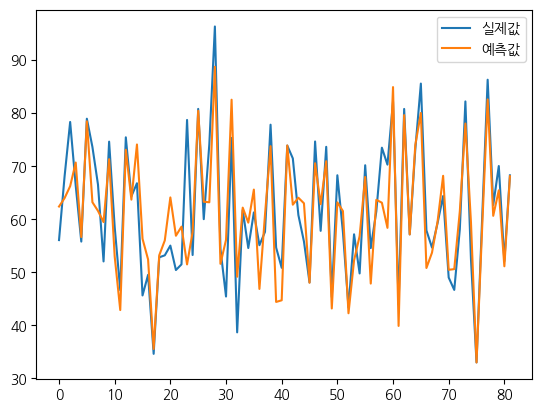

In [439]:
plt.plot(y_test.values)
plt.plot(y_pred)
plt.legend(['실제값','예측값'])
plt.show()

### [ 리그레션문제는 => 리니어리그레션, 랜덤포레스트, XG부스트를 이용하면 된다 ]